In [1]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, WeibullFitter, WeibullAFTFitter, CoxTimeVaryingFitter
from lifelines.statistics import survival_difference_at_fixed_point_in_time_test

from utils.utils import get_train_survival_dataset_time_varying
import constants.scania_component_x_columns as cols
import os

survival_dataset = get_train_survival_dataset_time_varying()

Generating survival dataset...
Survival dataset generated in 0:18:08.028936.
Saving survival dataset to survival_dataset_time_varying.csv...


C:\Users\Epulapp\PycharmProjects\SurvivalAnalysisScaniaComponentX\.venv\Lib\site-packages\lifelines\utils\__init__.py:1120: ConvergenceWarning: Column Spec_1_Cat26 have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['in_study_repair'].astype(bool)
>>> print(df.loc[events, 'Spec_1_Cat26'].var())
>>> print(df.loc[~events, 'Spec_1_Cat26'].var())

A very low variance means that the column Spec_1_Cat26 completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


Iteration 1: norm_delta = 3.18e-02, step_size = 0.9500, log_lik = -21227.01085, newton_decrement = 7.84e+01, seconds_since_start = 97.8
Iteration 2: norm_delta = 1.22e-03, step_size = 0.9500, log_lik = -21149.65256, newton_decrement = 1.06e-01, seconds_since_start = 189.6
Iteration 3: norm_delta = 6.14e-05, step_size = 0.9500, log_lik = -21149.54634, newton_decrement = 2.69e-04, seconds_since_start = 298.6
Iteration 4: norm_delta = 3.23e-06, step_size = 1.0000, log_lik = -21149.54607, newton_decrement = 6.72e-07, seconds_since_start = 427.9
Iteration 5: norm_delta = 1.53e-11, step_size = 1.0000, log_lik = -21149.54607, newton_decrement = 1.74e-17, seconds_since_start = 508.2
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 1121648 periods, 23550 subjects, 2272 events>
         event col = 'in_study_repair'
         penalizer = 0.1
number of subjects = 23550
 number of periods = 1121648
  number of events = 2272
partial log-likelihood = -21149.55
  time fit was run = 2026-05-29 09:27:44 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
100_0         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
158_0         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
158_1         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
158_2         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
158_3         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
158_4         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
158_5         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
158_6         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
158_7         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
158_8         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
158_9         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
167_0        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
167_1         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
167_2        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
167_3        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
167_4         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
167_5         0.00      1.00      0.00            0.00            0.00                1.00                1.00
167_6         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
167_7         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
167_8         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
167_9         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
171_0         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
272_0         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
272_1        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
272_2         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
272_3         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
272_4         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
272_5         0.00      1.00      0.00            0.00            0.00                1.00                1.00
272_6         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
272_7         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
272_8         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
272_9         0

<Axes: xlabel='log(HR) (95% CI)'>

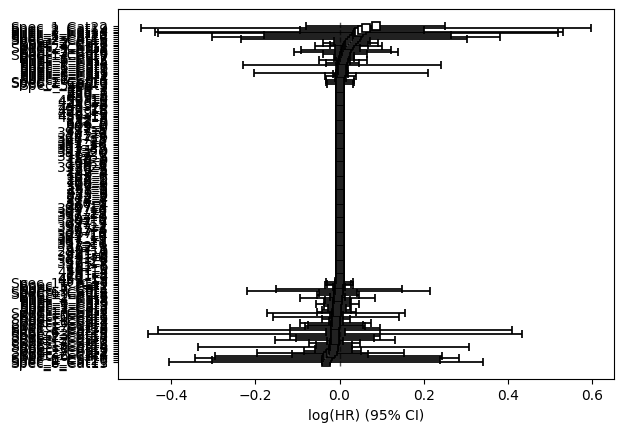

In [13]:
from lifelines import CoxTimeVaryingFitter

survival_dataset = survival_dataset.fillna(0)

# We drop these columns because they generate ConvergenceWarning.
survival_dataset = survival_dataset.drop(columns=['Spec_1_Cat25', 'Spec_1_Cat27', 'Spec_6_Cat11', 'Spec_6_Cat17', 'Spec_6_Cat18', 'Spec_1_Cat21'], axis=1)

ctv = CoxTimeVaryingFitter(penalizer=0.1)
ctv.fit(survival_dataset, id_col=cols.VEHICLE_ID, event_col=cols.IN_STUDY_REPAIR, start_col="start", stop_col="stop", show_progress=True)
ctv.print_summary()
ctv.plot()

In [12]:
events = survival_dataset[cols.IN_STUDY_REPAIR].astype(bool)
print(survival_dataset.loc[events, 'Spec_1_Cat21'].var())
print(survival_dataset.loc[~events, 'Spec_1_Cat21'].var())

number_spec_1_cat_21 = survival_dataset.loc[(survival_dataset['Spec_1_Cat21'] == 1) & (survival_dataset[cols.IN_STUDY_REPAIR] == 1)]

print(number_spec_1_cat_21.shape)

0.0
0.0004018484383151302
(0, 191)
